In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

In [2]:
dataset_path = "https://archive.ics.uci.edu/static/public/222/bank+marketing.zip"

In [3]:
# !wget $dataset_path

In [4]:
columns = ['age', 'job', 'marital', 'education', 'balance', 'housing', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']

### [Data preparation](https://github.com/DataTalksClub/machine-learning-zoomcamp/blob/master/cohorts/2024/03-classification/homework.md#data-preparation)

-   Select only the features from above.
-   Check if the missing values are presented in the features.

In [5]:
df = pd.read_csv('bank+marketing/bank/bank-full.csv', sep=';')

In [6]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [7]:
df = df[columns]

In [8]:
df.columns

Index(['age', 'job', 'marital', 'education', 'balance', 'housing', 'contact',
       'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome',
       'y'],
      dtype='object')

In [9]:
df.isnull().sum()

age          0
job          0
marital      0
education    0
balance      0
housing      0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

No missing values in the features.

### [Question 1](https://github.com/DataTalksClub/machine-learning-zoomcamp/blob/master/cohorts/2024/03-classification/homework.md#question-1)

What is the most frequent observation (mode) for the column `education`?

-   `unknown`
-   `primary`
-   **`secondary`**
-   `tertiary`

Secondary

In [10]:
df.mode()

,age,job,marital,education,balance,housing,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,32,blue-collar,married,secondary,0,yes,cellular,20,may,124,1,-1,0,unknown,no


### [Question 2](https://github.com/DataTalksClub/machine-learning-zoomcamp/blob/master/cohorts/2024/03-classification/homework.md#question-2)

Create the [correlation matrix](https://www.google.com/search?q=correlation+matrix) for the numerical features of your dataset. In a correlation matrix, you compute the correlation coefficient between every pair of features.

What are the two features that have the biggest correlation?

-   `age` and `balance`
-   `day` and `campaign`
-   `day` and `pdays`
-   **`pdays` and `previous`**

In [11]:
corrM = df.corr(numeric_only=True)
corrM

,age,balance,day,duration,campaign,pdays,previous
age,1.000000,0.097783,-0.009120,-0.004648,0.004760,-0.023758,0.001288
balance,0.097783,1.000000,0.004503,0.021560,-0.014578,0.003435,0.016674
day,-0.009120,0.004503,1.000000,-0.030206,0.162490,-0.093044,-0.051710
duration,-0.004648,0.021560,-0.030206,1.000000,-0.084570,-0.001565,0.001203
campaign,0.004760,-0.014578,0.162490,-0.084570,1.000000,-0.088628,-0.032855
pdays,-0.023758,0.003435,-0.093044,-0.001565,-0.088628,1.000000,0.454820
previous,0.001288,0.016674,-0.051710,0.001203,-0.032855,0.454820,1.000000


<Axes: >

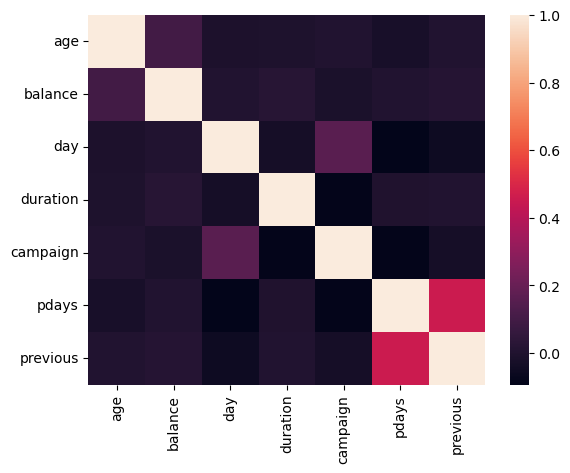

In [12]:
sns.heatmap(corrM)

### [Target encoding](https://github.com/DataTalksClub/machine-learning-zoomcamp/blob/master/cohorts/2024/03-classification/homework.md#target-encoding)

-   Now we want to encode the `y` variable.
-   Let's replace the values `yes`/`no` with `1`/`0`.

In [13]:
df.head()

,age,job,marital,education,balance,housing,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,2143,yes,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,29,yes,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,2,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,1506,yes,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,1,no,unknown,5,may,198,1,-1,0,unknown,no


In [14]:
df['y'].value_counts()

y
no     39922
yes     5289
Name: count, dtype: int64

In [15]:
df.y

0         no
1         no
2         no
3         no
4         no
        ... 
45206    yes
45207    yes
45208    yes
45209     no
45210     no
Name: y, Length: 45211, dtype: object

In [16]:
df.y = (df.y == 'yes').astype('int')

### [Split the data](https://github.com/DataTalksClub/machine-learning-zoomcamp/blob/master/cohorts/2024/03-classification/homework.md#split-the-data)

-   Split your data in train/val/test sets with 60%/20%/20% distribution.
-   Use Scikit-Learn for that (the `train_test_split` function) and set the seed to `42`.
-   Make sure that the target value `y` is not in your dataframe.

In [17]:
from sklearn.model_selection import train_test_split

In [18]:
df_fulltrain, df_test = train_test_split(df, test_size=0.2, random_state=42)
df_train, df_val = train_test_split(df_fulltrain, test_size=0.25, random_state=42)

df_fulltrain.reset_index(drop=True)
df_train.reset_index(drop=True)
df_test.reset_index(drop=True)
df_val.reset_index(drop=True)

y_fulltrain = df_fulltrain.y.values
y_train = df_train.y.values
y_test = df_test.y.values
y_val = df_val.y.values

del df_fulltrain['y']
del df_train['y']
del df_test['y']
del df_val['y']

In [19]:
print(len(df_train), len(df_test), len(df_val))

27126 9043 9042


### [Question 3](https://github.com/DataTalksClub/machine-learning-zoomcamp/blob/master/cohorts/2024/03-classification/homework.md#question-3)

-   Calculate the mutual information score between `y` and other categorical variables in the dataset. Use the training set only.
-   Round the scores to 2 decimals using `round(score, 2)`.

Which of these variables has the biggest mutual information score?

-   `contact`
-   `education`
-   `housing`
-   **`poutcome`**

In [20]:
from sklearn.metrics import mutual_info_score

In [21]:
df.dtypes

age           int64
job          object
marital      object
education    object
balance       int64
housing      object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
y             int64
dtype: object

In [22]:
df.head()

,age,job,marital,education,balance,housing,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,2143,yes,unknown,5,may,261,1,-1,0,unknown,0
1,44,technician,single,secondary,29,yes,unknown,5,may,151,1,-1,0,unknown,0
2,33,entrepreneur,married,secondary,2,yes,unknown,5,may,76,1,-1,0,unknown,0
3,47,blue-collar,married,unknown,1506,yes,unknown,5,may,92,1,-1,0,unknown,0
4,33,unknown,single,unknown,1,no,unknown,5,may,198,1,-1,0,unknown,0


In [23]:
categorical_columns = df_train.dtypes[df.dtypes == 'object'].index
numerical_columns = df_train.dtypes[df.dtypes != 'object'].index

In [24]:
categorical_columns

Index(['job', 'marital', 'education', 'housing', 'contact', 'month',
       'poutcome'],
      dtype='object')

In [25]:
numerical_columns

Index(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous'], dtype='object')

In [26]:
def mutual_info_churn_score(series):
    return mutual_info_score(series, y_train)

In [27]:
mi = df_train[categorical_columns].apply(mutual_info_churn_score)
mi.sort_values(ascending=False)

poutcome     0.029533
month        0.025090
contact      0.013356
housing      0.010343
job          0.007316
education    0.002697
marital      0.002050
dtype: float64

### [Question 4](https://github.com/DataTalksClub/machine-learning-zoomcamp/blob/master/cohorts/2024/03-classification/homework.md#question-4)

-   Now let's train a logistic regression.
-   Remember that we have several categorical variables in the dataset. Include them using one-hot encoding.
-   Fit the model on the training dataset.
    -   To make sure the results are reproducible across different versions of Scikit-Learn, fit the model with these parameters:
    -   `model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000, random_state=42)`
-   Calculate the accuracy on the validation dataset and round it to 2 decimal digits.

What accuracy did you get?

-   0.6
-   0.7
-   0.8
-   0.9

In [28]:
from sklearn.feature_extraction import DictVectorizer

In [29]:
dv = DictVectorizer(sparse=False)

train_dict = df_train.to_dict(orient='records')
X_train = dv.fit_transform(train_dict)

val_dict = df_val.to_dict(orient='records')
X_val = dv.transform(val_dict)

In [30]:
X_train

array([[3.200e+01, 1.100e+03, 1.000e+00, ..., 0.000e+00, 1.000e+00,
        0.000e+00],
       [3.800e+01, 0.000e+00, 1.000e+00, ..., 0.000e+00, 1.000e+00,
        0.000e+00],
       [4.900e+01, 3.309e+03, 2.000e+00, ..., 0.000e+00, 1.000e+00,
        0.000e+00],
       ...,
       [5.400e+01, 0.000e+00, 1.000e+00, ..., 0.000e+00, 1.000e+00,
        0.000e+00],
       [2.500e+01, 2.311e+03, 2.000e+00, ..., 0.000e+00, 1.000e+00,
        0.000e+00],
       [3.000e+01, 1.500e+01, 2.000e+00, ..., 0.000e+00, 1.000e+00,
        0.000e+00]])

In [31]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [32]:
from sklearn.linear_model import LogisticRegression

In [33]:
model = LogisticRegression(solver='lbfgs', random_state=42)
model.fit(X_train, y_train)

/Users/tranchau/anaconda3/envs/ml-zoomcamp/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(random_state=42)

In [34]:
y_pred = model.predict_proba(X_val)[:, 1]

In [35]:
y_decision = (y_pred >= 0.5)

In [36]:
score = round((y_val == y_decision).mean(), 2)
score

0.89

### [Question 5](https://github.com/DataTalksClub/machine-learning-zoomcamp/blob/master/cohorts/2024/03-classification/homework.md#question-5)

-   Let's find the least useful feature using the _feature elimination_ technique.
-   Train a model with all these features (using the same parameters as in Q4).
-   Now exclude each feature from this set and train a model without it. Record the accuracy for each model.
-   For each feature, calculate the difference between the original accuracy and the accuracy without the feature.

Which of following feature has the smallest difference?

-   `age`
-   `balance`
-   `marital`
-   `previous`

> **Note**: The difference doesn't have to be positive.

In [37]:
dv = DictVectorizer(sparse=False)

columns = df_train.columns.tolist()
columns.remove('age')

train_dict = df_train[columns].to_dict(orient='records')
X_train = dv.fit_transform(train_dict)

val_dict = df_val[columns].to_dict(orient='records')
X_val = dv.transform(val_dict)
X_train

model = LogisticRegression(solver='lbfgs', random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict_proba(X_val)[:, 1]
y_decision = (y_pred >= 0.5)
(y_val == y_decision).mean()
df_pred = pd.DataFrame()
df_pred['probability'] = y_pred
df_pred['prediction'] = y_decision.astype(int)
df_pred['actual'] = y_val
df_pred['correct'] = df_pred.prediction == df_pred.actual
df_pred.correct.mean()

/Users/tranchau/anaconda3/envs/ml-zoomcamp/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.8943817739438178

In [38]:
dv = DictVectorizer(sparse=False)

train_dict = df_train.to_dict(orient='records')
X_train = dv.fit_transform(train_dict)

val_dict = df_val.to_dict(orient='records')
X_val = dv.transform(val_dict)

In [39]:
X_train

array([[3.200e+01, 1.100e+03, 1.000e+00, ..., 0.000e+00, 1.000e+00,
        0.000e+00],
       [3.800e+01, 0.000e+00, 1.000e+00, ..., 0.000e+00, 1.000e+00,
        0.000e+00],
       [4.900e+01, 3.309e+03, 2.000e+00, ..., 0.000e+00, 1.000e+00,
        0.000e+00],
       ...,
       [5.400e+01, 0.000e+00, 1.000e+00, ..., 0.000e+00, 1.000e+00,
        0.000e+00],
       [2.500e+01, 2.311e+03, 2.000e+00, ..., 0.000e+00, 1.000e+00,
        0.000e+00],
       [3.000e+01, 1.500e+01, 2.000e+00, ..., 0.000e+00, 1.000e+00,
        0.000e+00]])

In [40]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [41]:
from sklearn.linear_model import LogisticRegression

In [42]:
model = LogisticRegression(solver='lbfgs', random_state=42)
model.fit(X_train, y_train)

/Users/tranchau/anaconda3/envs/ml-zoomcamp/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(random_state=42)

In [43]:
y_pred = model.predict_proba(X_val)[:, 1]

In [44]:
y_decision = (y_pred >= 0.5)

In [45]:
score = (y_val == y_decision).mean()
score = round(score, 2)

In [46]:
original_score = score
res = pd.DataFrame(columns=['eliminated_feature', 'accuracy', 'difference'])
columns = df_train.columns.tolist()
    
for eliminated_feature in columns:
    new_columns = columns.copy()
    new_columns.remove(eliminated_feature)
    
    dv = DictVectorizer(sparse=False)    

    train_dict = df_train[new_columns].to_dict(orient='records')
    X_train = dv.fit_transform(train_dict)

    val_dict = df_val[new_columns].to_dict(orient='records')
    X_val = dv.transform(val_dict)

    model = LogisticRegression(solver='liblinear', max_iter=1000, random_state=42)
    model.fit(X_train, y_train)
    
    y_pred = model.predict_proba(X_val)[:, 1]
    y_decision = (y_pred >= 0.5)
    
    score = (y_val == y_decision).mean()
    res.loc[len(res)] = [eliminated_feature, score, abs(original_score - score)]

In [47]:
res

,eliminated_feature,accuracy,difference
0,age,0.901239,0.011239
1,job,0.901128,0.011128
2,marital,0.900133,0.010133
3,education,0.901017,0.011017
4,balance,0.901460,0.011460
5,housing,0.900796,0.010796
6,contact,0.900464,0.010464
7,day,0.901239,0.011239
8,month,0.899690,0.009690
9,duration,0.889073,0.000927


In [48]:
min_diff = res.difference.min()
res.sort_values(by='difference')

,eliminated_feature,accuracy,difference
9,duration,0.889073,0.000927
13,poutcome,0.893829,0.003829
8,month,0.899690,0.009690
2,marital,0.900133,0.010133
6,contact,0.900464,0.010464
10,campaign,0.900686,0.010686
5,housing,0.900796,0.010796
3,education,0.901017,0.011017
11,pdays,0.901017,0.011017
1,job,0.901128,0.011128


### [Question 6](https://github.com/DataTalksClub/machine-learning-zoomcamp/blob/master/cohorts/2024/03-classification/homework.md#question-6)

-   Now let's train a regularized logistic regression.
-   Let's try the following values of the parameter `C`: `[0.01, 0.1, 1, 10, 100]`.
-   Train models using all the features as in Q4.
-   Calculate the accuracy on the validation dataset and round it to 3 decimal digits.

Which of these `C` leads to the best accuracy on the validation set?

-   0.01
-   0.1
-   1
-   10
-   100

> **Note**: If there are multiple options, select the smallest `C`.

In [49]:
res = pd.DataFrame(columns=['C', 'accuracy'])
Cs = [0.01, 0.1, 1, 10, 100]    

for C in Cs:
    dv = DictVectorizer(sparse=False)    

    train_dict = df_train.to_dict(orient='records')
    X_train = dv.fit_transform(train_dict)

    val_dict = df_val.to_dict(orient='records')
    X_val = dv.transform(val_dict)

    model = LogisticRegression(solver='liblinear', C=C, max_iter=1000, random_state=42)
    model.fit(X_train, y_train)
    
    y_pred = model.predict_proba(X_val)[:, 1]
    y_decision = (y_pred >= 0.5)
    
    score = round((y_val == y_decision).mean(), 3)
    res.loc[len(res)] = [C, score]

In [50]:
res

,C,accuracy
0,0.01,0.898
1,0.10,0.901
2,1.00,0.901
3,10.00,0.901
4,100.00,0.902
